<a href="https://colab.research.google.com/github/zeynep-serra/ML_Notes/blob/main/R/R_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# simple linear regression

# install.packages('caTools')
data = read.csv('salary_data.csv')

library(caTools)
split = sample.split(data$Salary, SplitRatio = 0.8)
training_set = subset(data, split == TRUE)
test_set = subset(data, split == FALSE)

regressor = lm(formula = Salary ~ YearsExperience, data = training_set)

summary(regressor)


Call:
lm(formula = Salary ~ YearsExperience, data = training_set)

Residuals:
    Min      1Q  Median      3Q     Max 
-8711.4 -4396.9   -21.8  4810.8 10715.5 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)      26664.1     2628.0   10.15 9.26e-10 ***
YearsExperience   9426.7      434.5   21.70 2.42e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 5988 on 22 degrees of freedom
Multiple R-squared:  0.9553,	Adjusted R-squared:  0.9533 
F-statistic: 470.7 on 1 and 22 DF,  p-value: 2.417e-16


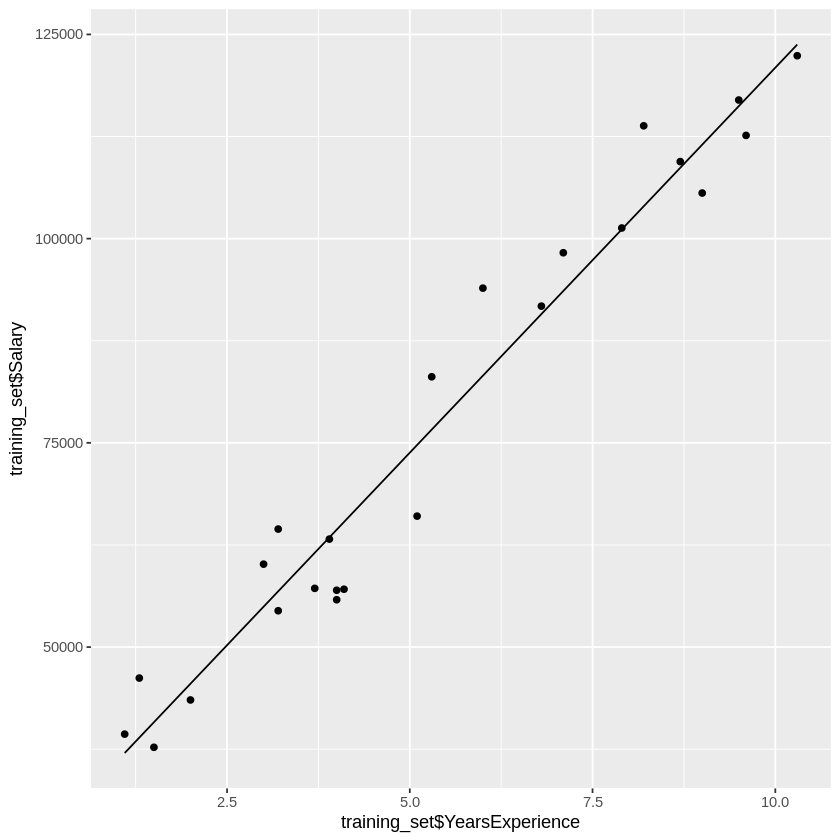

In [ ]:
# install.packages('ggplot2')
library(ggplot2)

ggplot() +
  geom_point(aes(x = training_set$YearsExperience, y = training_set$Salary)) +
  geom_line(aes(x = training_set$YearsExperience, y = predict(regressor, newdata = training_set)))

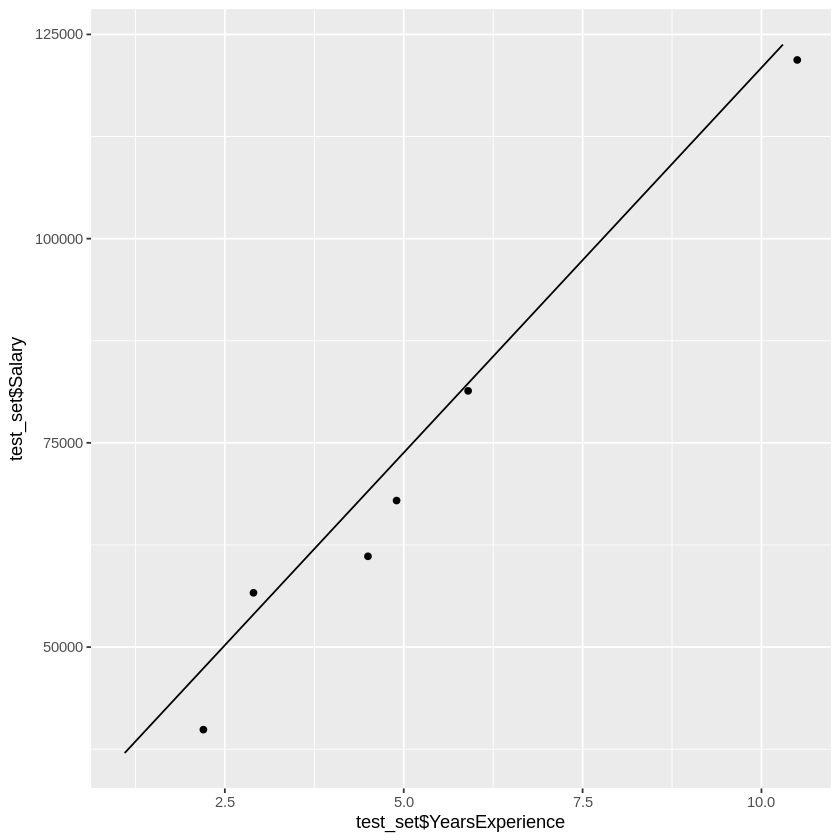

In [ ]:
y_pred = predict(regressor, newdata = test_set)

ggplot() +
  geom_point(aes(x = test_set$YearsExperience, y = test_set$Salary)) +
  geom_line(aes(x = training_set$YearsExperience, y = predict(regressor, newdata = training_set)))

In [ ]:
# multiple linear regression

data = read.csv('startups.csv')

data$State = factor(data$State,
  levels = c("New York", "California", "Florida"),
  labels = c(1, 2, 3))

split = sample.split(data$Profit, SplitRatio = 0.8)
training_set = subset(data, split == TRUE)
test_set = subset(data, split == FALSE)

regressor = lm(formula = Profit ~ .,
  data = training_set)

summary(regressor)


Call:
lm(formula = Profit ~ ., data = training_set)

Residuals:
   Min     1Q Median     3Q    Max 
-32913  -3214    294   7003  16818 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)      5.114e+04  7.856e+03   6.510 1.89e-07 ***
R.D.Spend        8.030e-01  5.516e-02  14.558 3.59e-16 ***
Administration  -3.137e-02  6.050e-02  -0.519    0.607    
Marketing.Spend  3.101e-02  2.032e-02   1.526    0.136    
State2          -1.277e+03  3.847e+03  -0.332    0.742    
State3          -5.786e+02  4.069e+03  -0.142    0.888    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 10030 on 34 degrees of freedom
Multiple R-squared:  0.9425,	Adjusted R-squared:  0.934 
F-statistic: 111.5 on 5 and 34 DF,  p-value: < 2.2e-16


In [ ]:
regressor = lm(formula = Profit ~ R.D.Spend + Marketing.Spend,
  data = training_set)

summary(regressor)


Call:
lm(formula = Profit ~ R.D.Spend + Marketing.Spend, data = training_set)

Residuals:
   Min     1Q Median     3Q    Max 
-33730  -2819    -79   5998  17194 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)     4.687e+04  3.128e+03   14.99   <2e-16 ***
R.D.Spend       7.923e-01  4.636e-02   17.09   <2e-16 ***
Marketing.Spend 3.402e-02  1.762e-02    1.93   0.0613 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 9666 on 37 degrees of freedom
Multiple R-squared:  0.9419,	Adjusted R-squared:  0.9387 
F-statistic: 299.7 on 2 and 37 DF,  p-value: < 2.2e-16



Call:
lm(formula = Salary ~ ., data = data)

Residuals:
    Min      1Q  Median      3Q     Max 
-112833  -68852   10682   55186  153364 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)   
(Intercept)   232167     115571   2.009  0.08451 . 
Level        -132871      48268  -2.753  0.02839 * 
Level2         19432       4276   4.544  0.00265 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 98260 on 7 degrees of freedom
Multiple R-squared:  0.9162,	Adjusted R-squared:  0.8923 
F-statistic: 38.27 on 2 and 7 DF,  p-value: 0.0001703


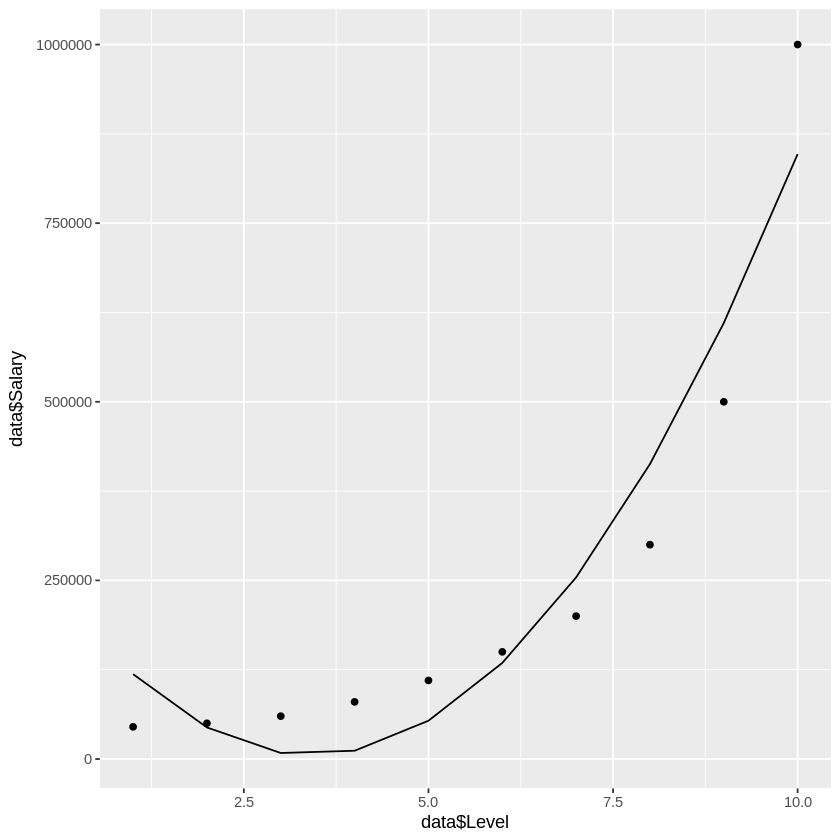

In [ ]:
# polynomial regression

data = read.csv("salaries.csv")
data = data[2:3]

data$Level2 = data$Level ^ 2
poly_reg = lm(formula = Salary ~ ., data = data)

summary(poly_reg)

ggplot() +
  geom_point(aes(x = data$Level, y = data$Salary)) +
  geom_line(aes(x = data$Level, y = predict(poly_reg, newdata = data)))


Call:
lm(formula = Salary ~ ., data = data)

Residuals:
   Min     1Q Median     3Q    Max 
-75695 -28148   7091  29256  49538 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)   
(Intercept) -121333.3    97544.8  -1.244  0.25994   
Level        180664.3    73114.5   2.471  0.04839 * 
Level2       -48549.0    15081.0  -3.219  0.01816 * 
Level3         4120.0      904.3   4.556  0.00387 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 50260 on 6 degrees of freedom
Multiple R-squared:  0.9812,	Adjusted R-squared:  0.9718 
F-statistic: 104.4 on 3 and 6 DF,  p-value: 1.441e-05


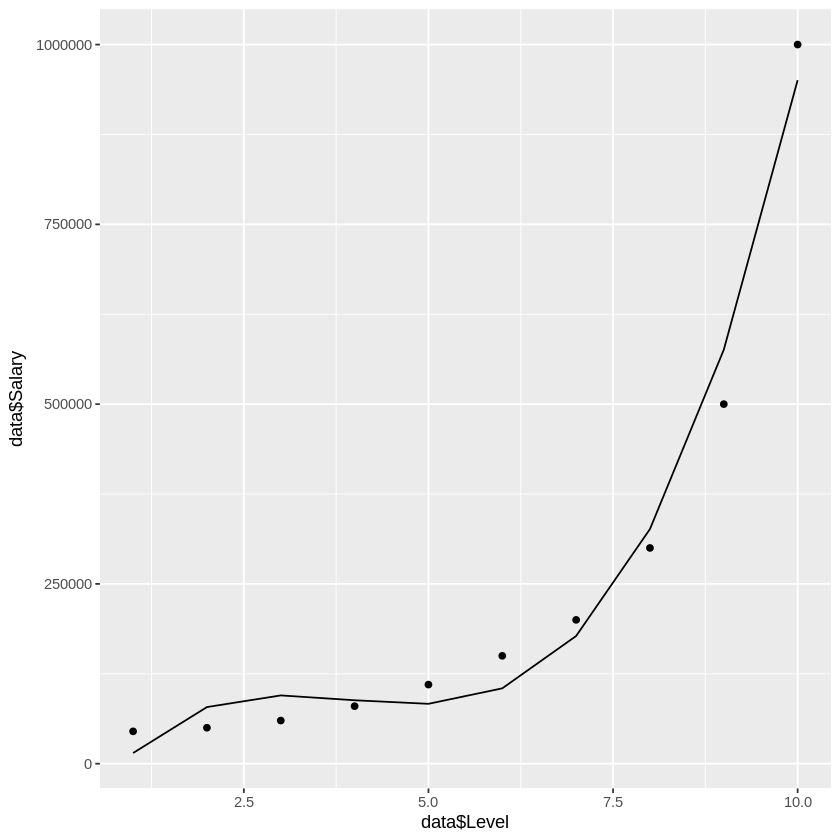

In [ ]:
data$Level2 = data$Level ^ 2
data$Level3 = data$Level ^ 3
poly_reg = lm(formula = Salary ~ ., data = data)

summary(poly_reg)

ggplot() +
  geom_point(aes(x = data$Level, y = data$Salary)) +
  geom_line(aes(x = data$Level, y = predict(poly_reg, newdata = data)))


Call:
lm(formula = Salary ~ ., data = data)

Residuals:
     1      2      3      4      5      6      7      8      9     10 
 -8357  18240   1358 -14633 -11725   6725  15997  10006 -28695  11084 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)   
(Intercept)  184166.7    67768.0   2.718  0.04189 * 
Level       -211002.3    76382.2  -2.762  0.03972 * 
Level2        94765.4    26454.2   3.582  0.01584 * 
Level3       -15463.3     3535.0  -4.374  0.00719 **
Level4          890.2      159.8   5.570  0.00257 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 20510 on 5 degrees of freedom
Multiple R-squared:  0.9974,	Adjusted R-squared:  0.9953 
F-statistic: 478.1 on 4 and 5 DF,  p-value: 1.213e-06


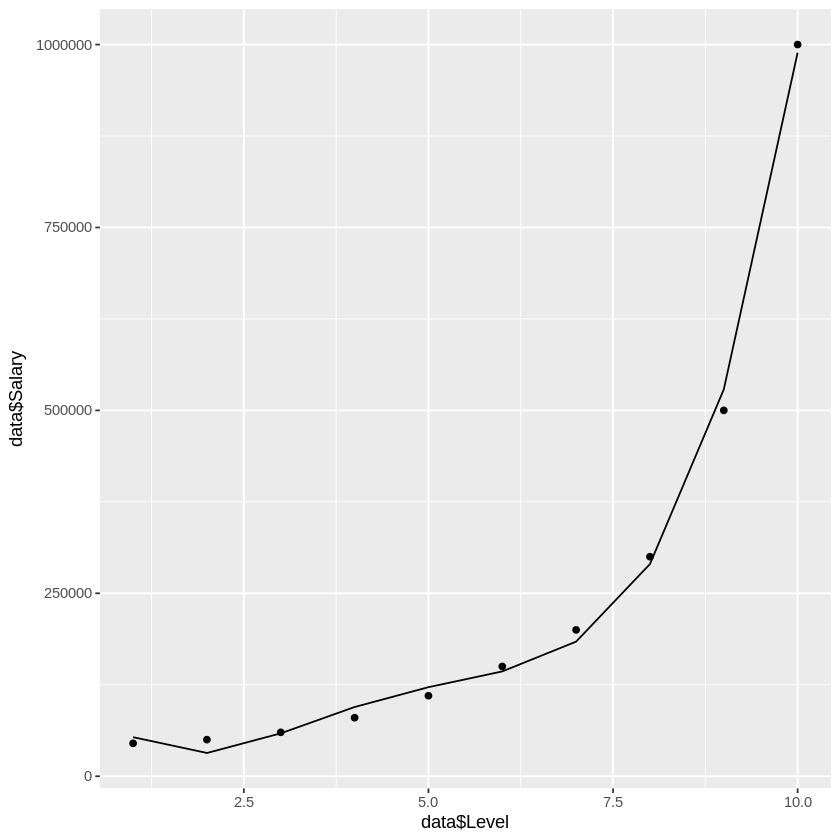

In [ ]:
data$Level2 = data$Level ^ 2
data$Level3 = data$Level ^ 3
data$Level4 = data$Level ^ 4
poly_reg = lm(formula = Salary ~ ., data = data)

summary(poly_reg)

ggplot() +
  geom_point(aes(x = data$Level, y = data$Salary)) +
  geom_line(aes(x = data$Level, y = predict(poly_reg, newdata = data)))


Attaching package: ‘e1071’


The following object is masked from ‘package:ggplot2’:

    element




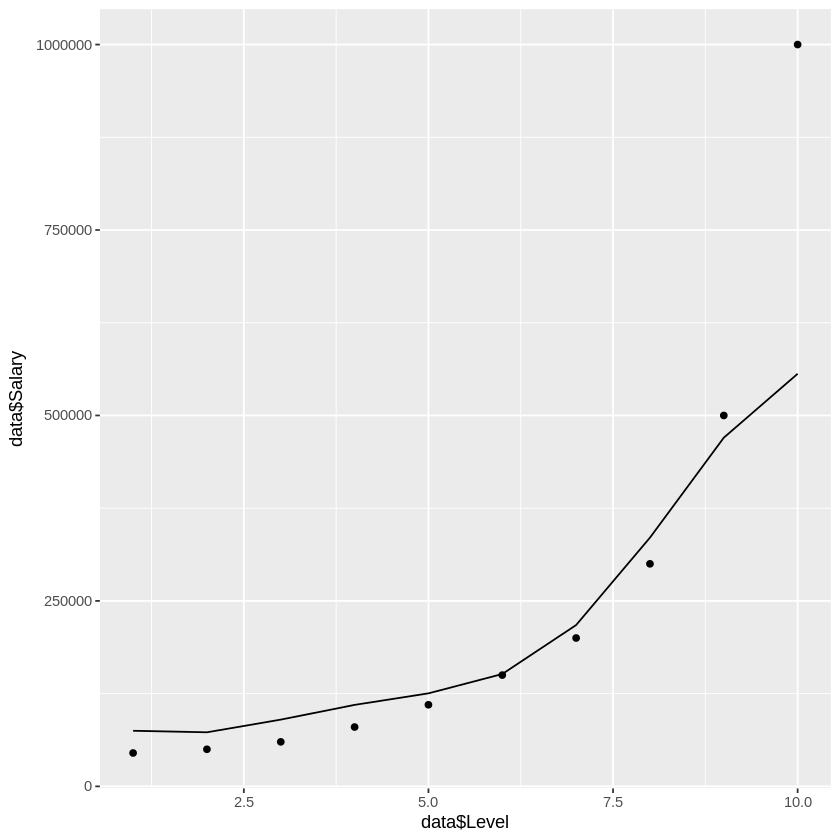

In [ ]:
# svr
# install.packages("e1071")
library(e1071)

data = read.csv("salaries.csv")
data = data[2:3]

regressor = svm(formula = Salary ~ ., data = data,
type = "eps-regression")

ggplot() +
  geom_point(aes(x = data$Level, y = data$Salary)) +
  geom_line(aes(x = data$Level, y = predict(regressor, newdata = data)))

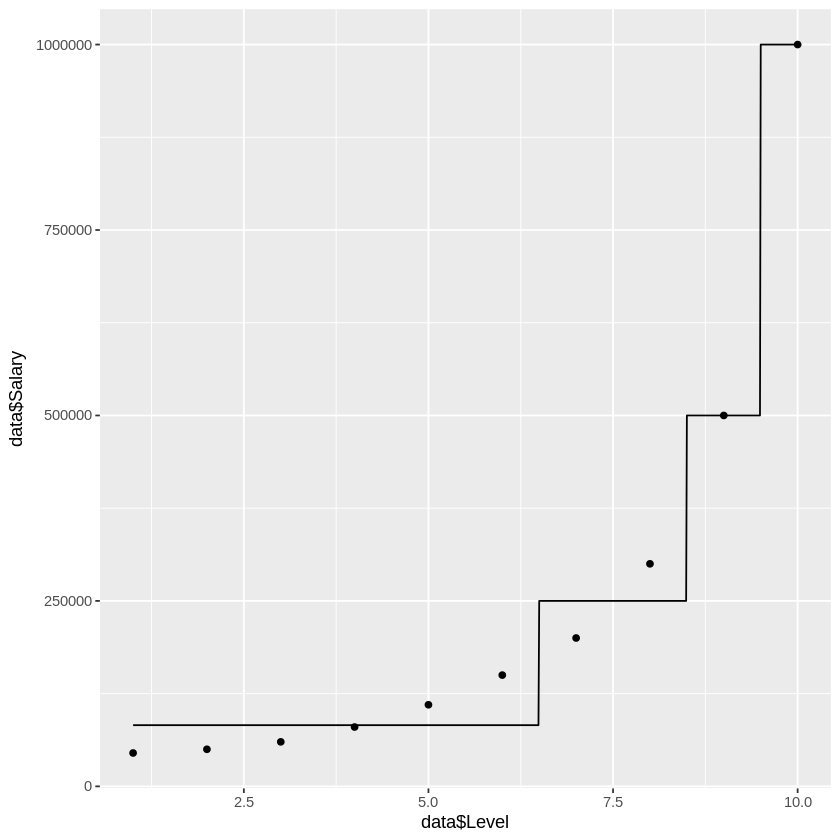

In [ ]:
# decision tree
# install.packages("rpart")
library(rpart)

regressor = rpart(formula = Salary ~ ., data = data,
control = rpart.control(minsplit = 1))

x_grid = seq(min(data$Level), max(data$Level), 0.01)
ggplot() +
  geom_point(aes(x = data$Level, y = data$Salary)) +
  geom_line(aes(x = x_grid, y = predict(regressor,
  newdata = data.frame(Level = x_grid))))

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:ggplot2’:

    margin




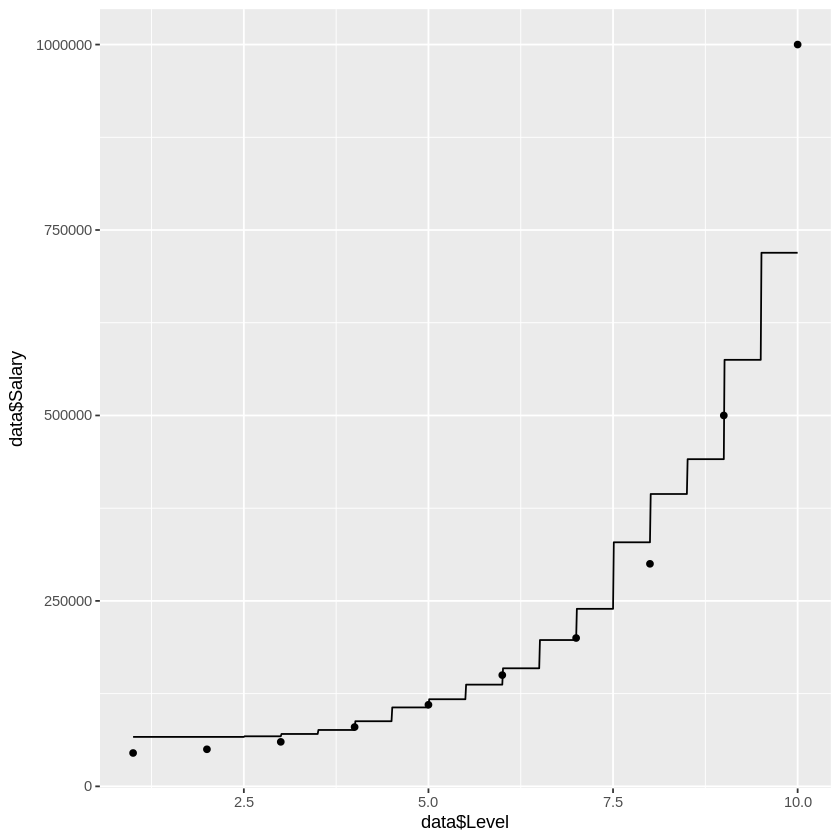

In [ ]:
# random forest
# install.packages("randomForest")
library(randomForest)

regressor = randomForest(x = data[1], y = data$Salary, ntree = 100)

x_grid = seq(min(data$Level), max(data$Level), 0.01)
ggplot() +
  geom_point(aes(x = data$Level, y = data$Salary)) +
  geom_line(aes(x = x_grid, y = predict(regressor,
  newdata = data.frame(Level = x_grid))))